# 中金所固定合约对的日度 spread 分位数研究

本研究将同一事件的旧主力、展入新主力固定为一对合约。只从 backtest_1s 读取同秒 BBO，不使用 HFQ、连续合约、日线 close 或滚动平滑。目标是把秒级盘口低频化为每分钟和每个交易日的价差分布，判断哪些品种可能存在可交易机会。

## 聚合口径

每秒只在旧、新腿同时有有效最优买卖价时配对。分别保存中间价差、卖旧买新价差、买旧卖新价差及其 bp 形式。

每分钟直接对该分钟内所有同秒 spread 求 mean、p10、p20、p50、p80、p90，至少要有 30 条同秒样本。这不是 rolling mean。每个交易日再直接对该日全部同秒 spread 计算相同的六个统计量，因此夜盘与日盘仍属于主力日历定义的同一 trading day。

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Cargo.toml').is_file():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('cannot locate the mkt_signal repository root')
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.roll_spread.quantile_study import QuantileParameters, run_ccfx_quantile_study
from research.roll_spread.study import StudyPaths

PATHS = StudyPaths(
    cn_roll_root=Path('/mnt/nvme-raid0-28t/fanghaizhou/cn_roll_replay/2019_20260826/result_no_rollback'),
    cme_roll_root=Path('/mnt/hdd-raid5-72t/liang_torch/lseg_data/cme_volume_roll_1d'),
    cn_backtest_root=Path('/mnt/hdd-raid5-72t/liang_torch/cn_futures_data/backtest_1s'),
    cme_backtest_root=Path('/mnt/hdd-raid5-72t/liang_torch/lseg_data/backtest_1s'),
)
OUTPUT_DIR = Path('/mnt/nvme-raid0-28t/fanghaizhou/roll_spread_study/20260909_ccfx_daily_quantiles')
PARAMETERS = QuantileParameters(pre_roll_days=10, min_seconds_per_minute=30)

# True 会从 1s BBO 重新汇总；False 直接读取本次已审计完成的结果。
REBUILD = False


In [2]:
if REBUILD:
    results = run_ccfx_quantile_study(
        PATHS, OUTPUT_DIR, recent_start=pd.Timestamp('2026-01-01'), parameters=PARAMETERS
    )
else:
    results = {
        'events': pd.read_csv(OUTPUT_DIR / 'events.csv', parse_dates=['event_date']),
        'audit': pd.read_csv(OUTPUT_DIR / 'backtest_file_audit.csv', parse_dates=['event_date', 'trading_day']),
        'daily': pd.read_csv(OUTPUT_DIR / 'daily_spread_distribution.csv', parse_dates=['event_date', 'trading_day']),
        'mid_path': pd.read_csv(OUTPUT_DIR / 'daily_mid_spread_path.csv'),
        'long_path': pd.read_csv(OUTPUT_DIR / 'daily_long_old_short_new_path.csv'),
        'short_path': pd.read_csv(OUTPUT_DIR / 'daily_short_old_long_new_path.csv'),
        'product_roll_manifest': pd.read_csv(OUTPUT_DIR / 'product_mid_spread_roll_manifest.csv'),
        'product_summary': pd.read_csv(OUTPUT_DIR / 'product_quantile_summary.csv'),
        'directional_summary': pd.read_csv(OUTPUT_DIR / 'product_directional_execution_summary.csv'),
    }

display(results['events'].groupby('product').agg(events=('event_id', 'size'), first_roll=('event_date', 'min'), last_roll=('event_date', 'max')))
display(results['audit'].groupby('status', as_index=False).agg(files=('status', 'size'), paired_seconds=('pair_seconds', 'sum'), minute_rows=('minute_rows', 'sum')))


,events,first_roll,last_roll
product,,,
IC,2,2026-03-12,2026-06-16
IF,2,2026-03-17,2026-06-15
IH,2,2026-03-18,2026-06-16
IM,2,2026-03-17,2026-06-16
T,3,2026-02-24,2026-08-21
TF,3,2026-02-13,2026-08-24
TL,3,2026-02-24,2026-08-24
TS,3,2026-02-24,2026-08-24


,status,files,paired_seconds,minute_rows
0,ok,200,2987590,49800


## 每个品种的换月叠加图

总览图不是单次换月，而是全部中金所事件的等权平均。以下每张小图只包含一个品种；同色线是一条固定旧/新合约对在一次换月前十个交易日的路径，图例写明换月日和合约对。

,product,product_name,events,rolls
0,IC,中证500股指期货,2,2026-03-12: IC2603 -> IC2606 | 2026-06-16: IC2...
1,IF,沪深300股指期货,2,2026-03-17: IF2603 -> IF2606 | 2026-06-15: IF2...
2,IH,上证50股指期货,2,2026-03-18: IH2603 -> IH2606 | 2026-06-16: IH2...
3,IM,中证1000股指期货,2,2026-03-17: IM2603 -> IM2606 | 2026-06-16: IM2...
4,T,10年期国债期货,3,2026-02-24: T2603 -> T2606 | 2026-05-25: T2606...
5,TF,5年期国债期货,3,2026-02-13: TF2603 -> TF2606 | 2026-05-25: TF2...
6,TL,30年期国债期货,3,2026-02-24: TL2603 -> TL2606 | 2026-05-21: TL2...
7,TS,2年期国债期货,3,2026-02-24: TS2603 -> TS2606 | 2026-05-26: TS2...


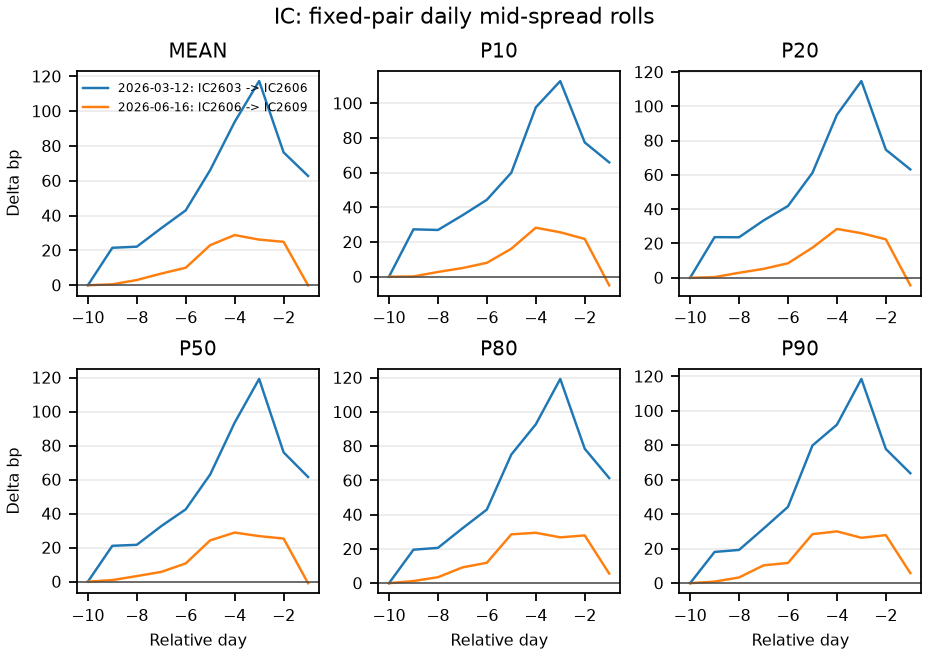

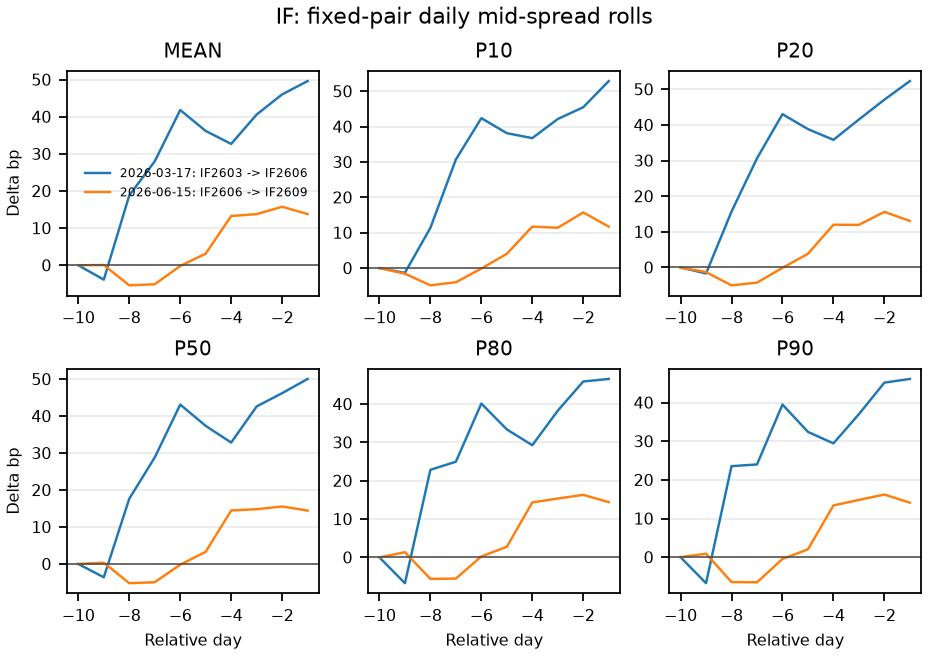

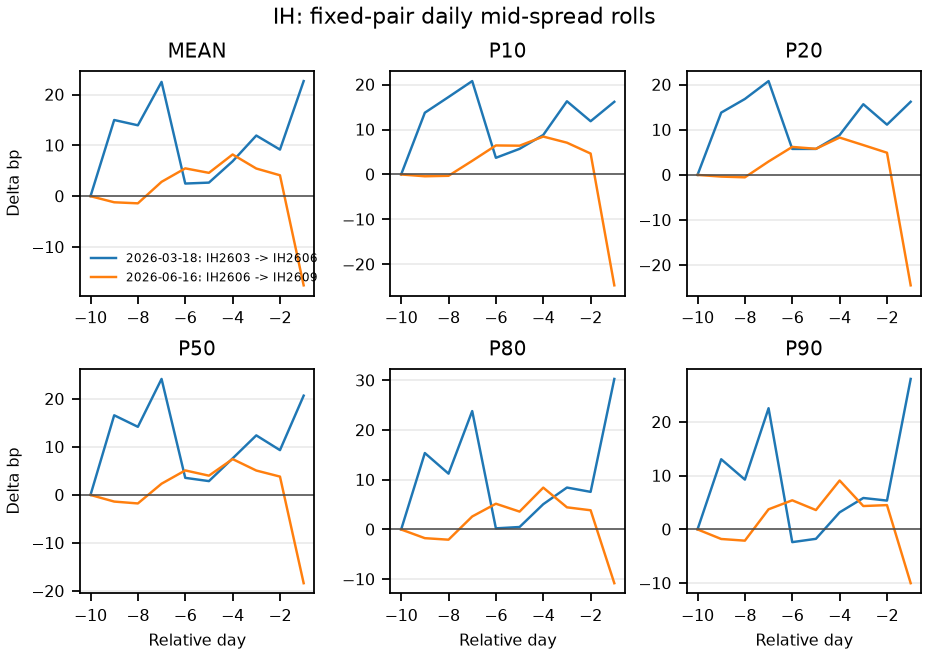

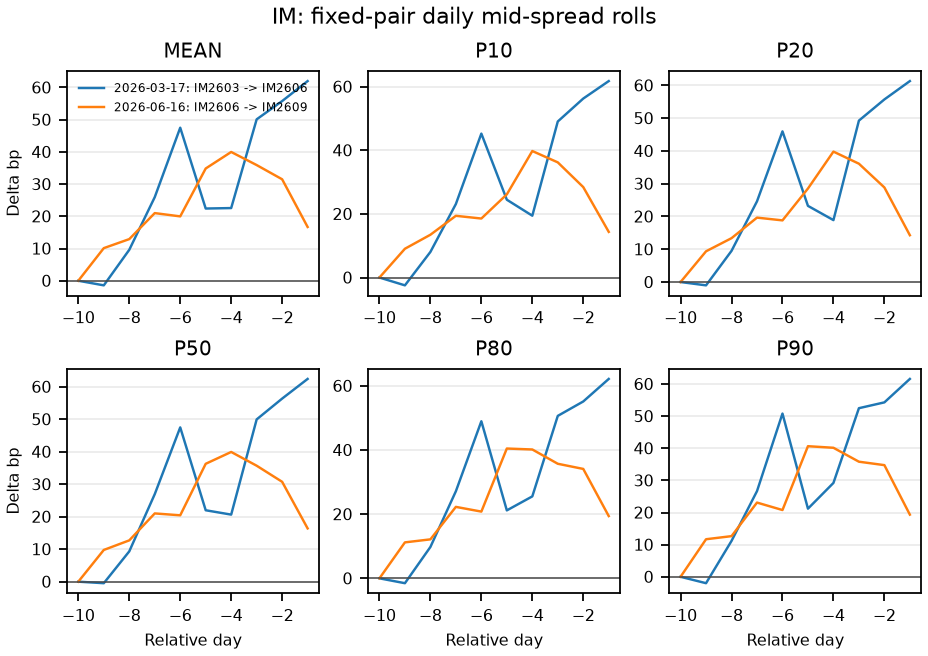

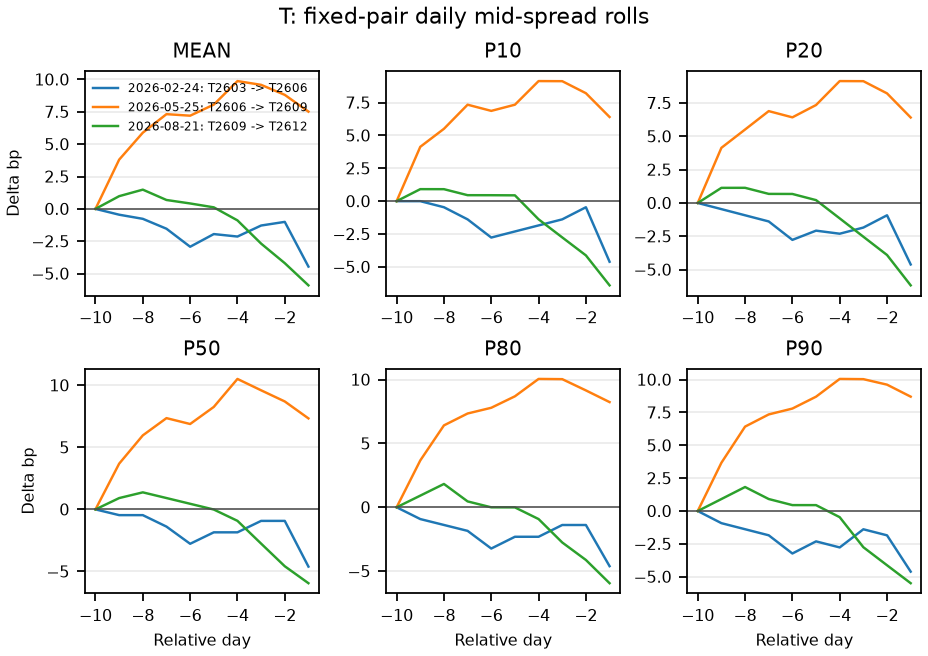

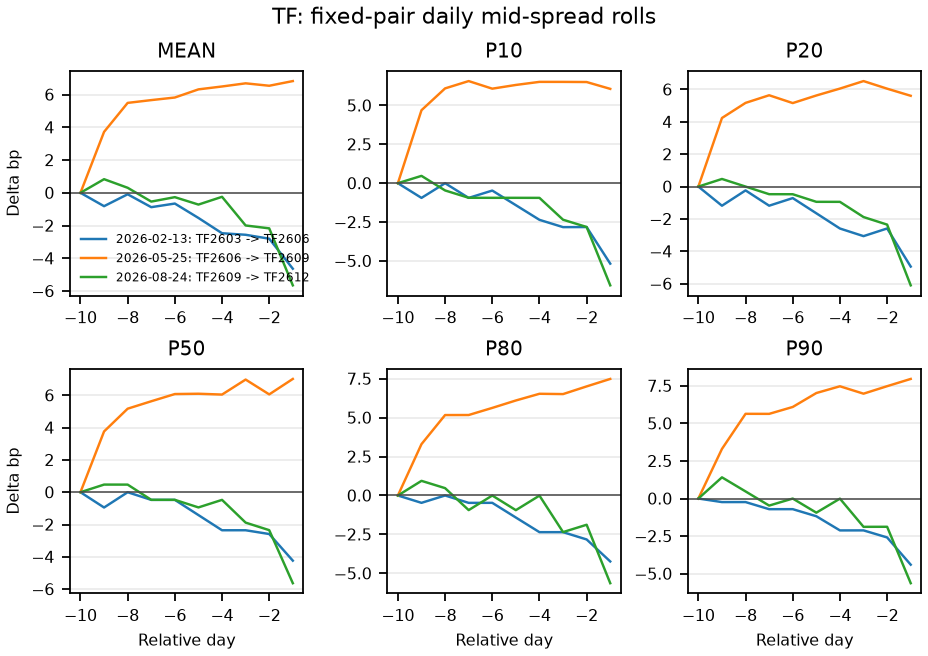

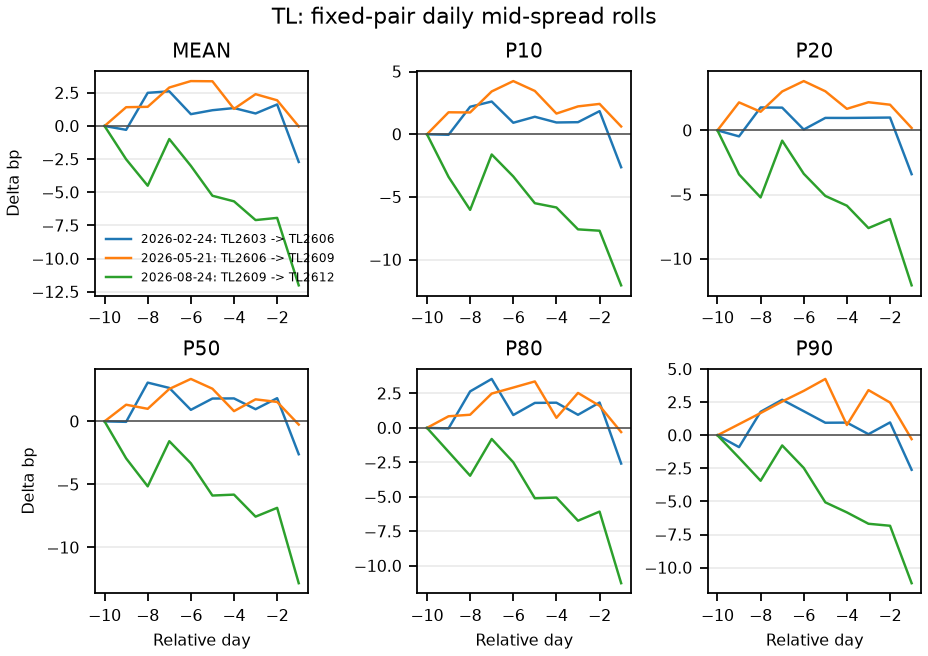

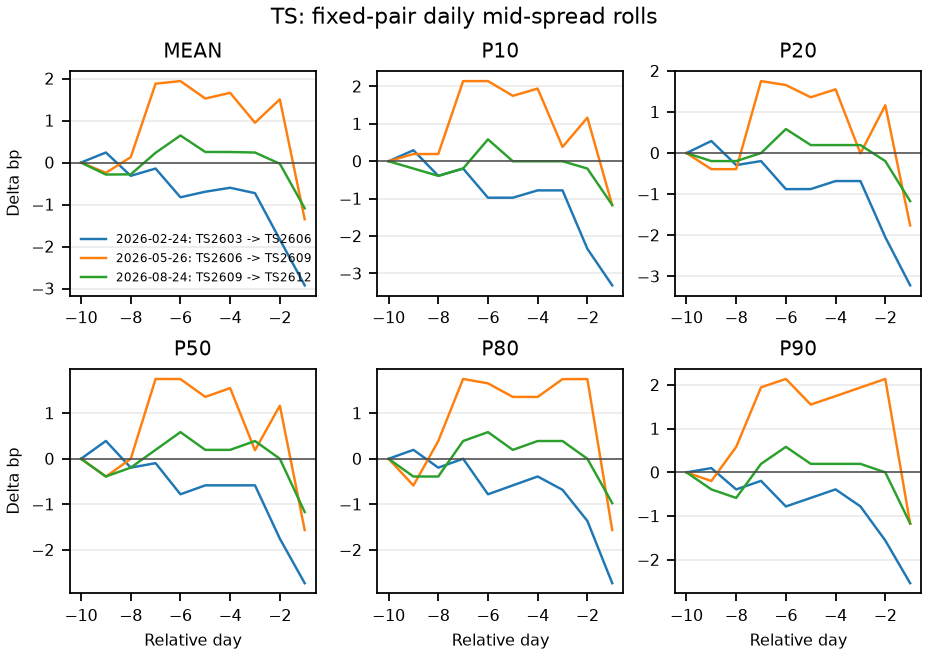

In [3]:
manifest = results['product_roll_manifest'].sort_values('product')
display(manifest[['product', 'product_name', 'events', 'rolls']])
for row in manifest.itertuples(index=False):
    display(Image(filename=str(OUTPUT_DIR / row.image_file)))


## 均值和五个日内分位数的逐日路径

中间价路径只说明旧合约相对新合约如何变化。多空交易则必须看对应的双腿 BBO，因此下方分为中间价、多旧空新和空旧多新三组六面板。每个小图均为 mean、p10、p20、p50、p80、p90 之一，并有独立纵轴。

,statistic,relative_day,mean_delta_bps,median_delta_bps,events
0,mean,-10,0.000000,0.000000,20
5,mean,-5,10.189612,2.904421,20
9,mean,-1,9.176773,-0.566365,20
10,p10,-10,0.000000,0.000000,20
15,p10,-5,9.530664,3.747893,20
19,p10,-1,8.158386,-1.172169,20
20,p20,-10,0.000000,0.000000,20
25,p20,-5,9.644138,3.443781,20
29,p20,-1,8.011579,-1.464627,20
30,p50,-10,0.000000,0.000000,20


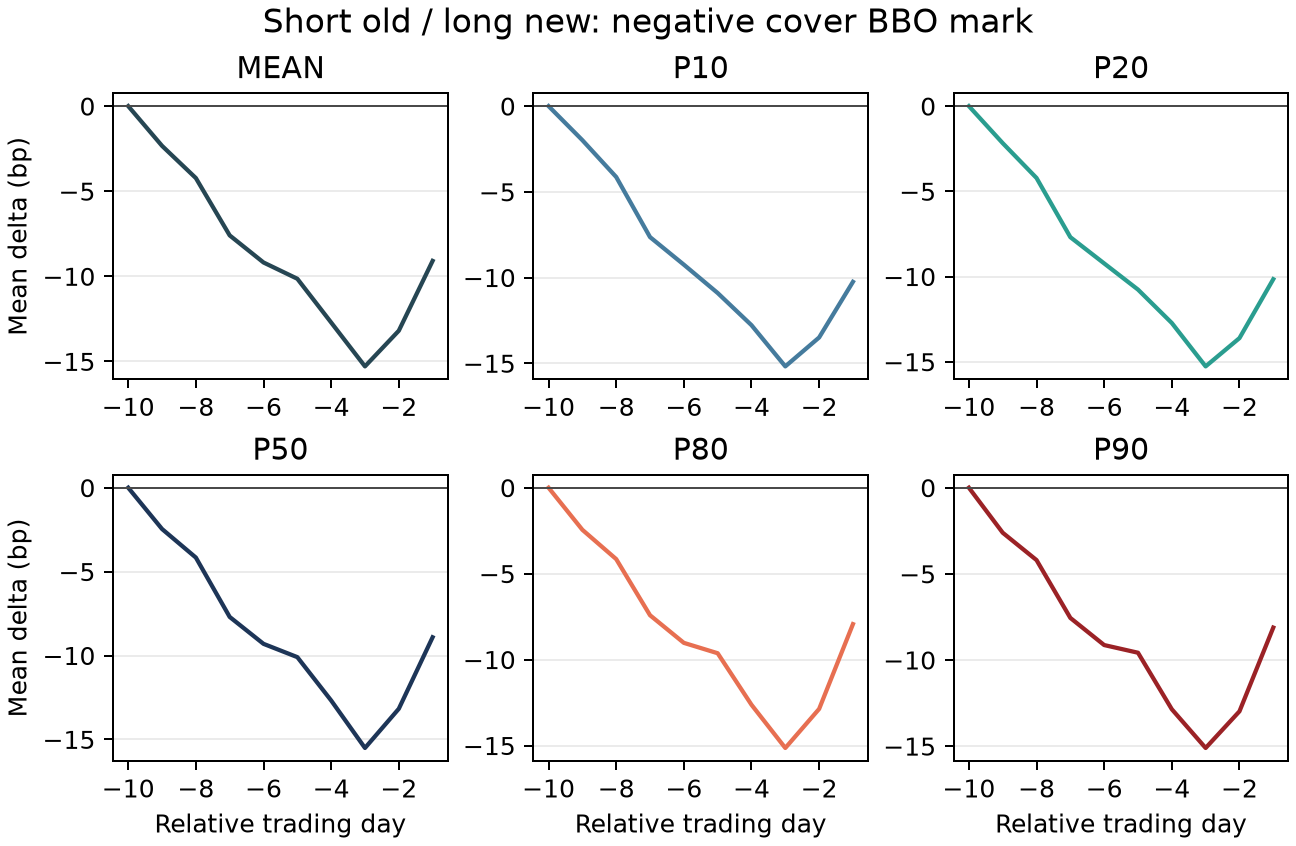

In [4]:
display(results['mid_path'].query('relative_day in [-10, -5, -1]').sort_values(['statistic', 'relative_day']))
Image(filename=str(OUTPUT_DIR / 'ccfx_mid_spread_panels.png'))
Image(filename=str(OUTPUT_DIR / 'ccfx_long_old_short_new_panels.png'))
Image(filename=str(OUTPUT_DIR / 'ccfx_short_old_long_new_panels.png'))


## 品种是否一致

下表保留每个品种的中文名称、逐事件斜率、首日结构延续和前半窗口动量延续的方向比例。正值和负值同时存在时，整体均值不能被理解成每个品种都有同一条趋势。

In [5]:
p50 = results['product_summary'].query("statistic == 'p50'").copy()
display(p50[['product', 'product_name', 'events', 'median_change_bps', 'median_slope_bps_per_trading_day', 'positive_slope_share', 'positive_state_continuation_share', 'positive_momentum_continuation_share']])


,product,product_name,events,median_change_bps,median_slope_bps_per_trading_day,positive_slope_share,positive_state_continuation_share,positive_momentum_continuation_share
3,IC,中证500股指期货,2,30.332405,6.038352,1.000000,0.500000,0.000000
9,IF,沪深300股指期货,2,32.246592,4.025942,1.000000,1.000000,1.000000
15,IH,上证50股指期货,2,1.153534,-0.013138,0.500000,0.500000,0.500000
21,IM,中证1000股指期货,2,39.405449,4.848873,1.000000,1.000000,0.500000
27,T,10年期国债期货,3,-4.607988,-0.287833,0.333333,0.333333,0.666667
33,TF,5年期国债期货,3,-4.236478,-0.411966,0.333333,0.666667,1.000000
39,TL,30年期国债期货,3,-2.606285,-0.136062,0.000000,0.666667,0.333333
45,TS,2年期国债期货,3,-1.565234,-0.031934,0.000000,0.333333,0.333333


## 多空双腿 BBO 机会筛选

在前 50% 预换月交易日结束时，分别检验固定的多旧空新和空旧多新两种方向。多旧空新用买旧卖新的 BBO 建仓、卖旧买新的 BBO 平仓；空旧多新方向相反。每个方向都对 mean、p10、p20、p50、p80、p90 保存独立的典型毛变化。

这个数值用于筛选，不是成交回测：每个日度统计量来自独立的秒级分布，不能代表同一秒可成交的精确价格，也未计手续费、盘口深度和实际同步成交。

In [6]:
display(results['directional_summary'].sort_values(['product', 'statistic']))


,product,product_name,statistic,events,median_long_old_short_new_gross_bps,positive_long_old_short_new_share,median_short_old_long_new_gross_bps,positive_short_old_long_new_share
0,IC,中证500股指期货,mean,2,-16.350405,0.000000,10.155269,1.000000
1,IC,中证500股指期货,p10,2,-11.289386,0.500000,4.052339,0.500000
2,IC,中证500股指期货,p20,2,-13.410785,0.000000,6.664468,0.500000
3,IC,中证500股指期货,p50,2,-16.622983,0.000000,10.142278,0.500000
4,IC,中证500股指期货,p80,2,-21.043526,0.000000,15.548286,1.000000
5,IC,中证500股指期货,p90,2,-21.980556,0.000000,16.605403,1.000000
6,IF,沪深300股指期货,mean,2,9.566230,1.000000,-14.540251,0.000000
7,IF,沪深300股指期货,p10,2,8.718894,1.000000,-13.728091,0.000000
8,IF,沪深300股指期货,p20,2,8.756470,1.000000,-13.944820,0.000000
9,IF,沪深300股指期货,p50,2,9.518632,1.000000,-14.406519,0.000000


## 结论边界

本 Notebook 回答的是中金所当前样本内的分位数路径和品种异质性，不把它直接升级为交易策略。具有稳定正向日度分位变化、正向延续比例，并且典型双腿 BBO 筛选也为正的品种，才是下一阶段逐秒同步成交回测的候选；其余品种不能因 mid spread 路径好看就视为机会。